In [14]:
from csv_reader import read_csv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
from aux import format_plot
from copy import deepcopy as copy

plt.rcParams['font.family'] = 'Helvetica'

BATCH_SIZE = 1
PARAMS_START = 2 + BATCH_SIZE
N_RULES = 60 + 16
N_TIMECONSTS = 36 + 32
N_PARAMS = N_RULES + N_TIMECONSTS

In [15]:
rule_names = [ # Define labels for all rules to be run during simulations
	r'',
	r'$y$',
	r'$x$',
	r'$x \, y$',
	r'$\tilde{y}$',
	r'$x \, \tilde{y}$',
	r'$\tilde{x}$',
	r'$\tilde{x} \, y$',
	r'$\tilde{y} \, y$',
	r'$\tilde{x} \, x$',

	r'$w$',
	r'$w y$',
	r'$w x$',
	r'$w x \, y$',
	r'$w \tilde{y}$',
	r'$w x \, \tilde{y}$',
	r'$w \tilde{x}$',
	r'$w \tilde{x} \, y$',
	r'$w \tilde{y} \, y$',
	r'$w \tilde{x} \, x$',
]

rule_names = [
	[r'$HD \rightarrow HD$ ' + r_name for r_name in rule_names],
	[r'$HD \rightarrow HR$ ' + r_name for r_name in rule_names],
	[r'$HR \rightarrow HD$ ' + r_name for r_name in rule_names],
]

rule_names_tripartite = [
	r'$\tilde{y}, z \sim y$',
	r'$\tilde{x}, z \sim y$',
	r'$x \tilde{y}, z \sim y$',
	r'$\tilde{x} y, z \sim y$',

	r'$w \tilde{y}, z \sim y$',
	r'$w \tilde{x}, z \sim y$',
	r'$w x \tilde{y}, z \sim y$',
	r'$w \tilde{x} y, z \sim y$',
]

rule_names += [
	[r'$HD \rightarrow HD, HR \sim HD$' + r_name for r_name in rule_names_tripartite],
	[r'$HR \rightarrow HD, HD \sim HD$' + r_name for r_name in rule_names_tripartite],
]

rule_names = [r for rs in rule_names for r in rs]
rule_names = np.array(rule_names, dtype=object)

In [16]:
for i, rn in enumerate(rule_names):
    print(i, rn)

0 $HD \rightarrow HD$ 
1 $HD \rightarrow HD$ $y$
2 $HD \rightarrow HD$ $x$
3 $HD \rightarrow HD$ $x \, y$
4 $HD \rightarrow HD$ $\tilde{y}$
5 $HD \rightarrow HD$ $x \, \tilde{y}$
6 $HD \rightarrow HD$ $\tilde{x}$
7 $HD \rightarrow HD$ $\tilde{x} \, y$
8 $HD \rightarrow HD$ $\tilde{y} \, y$
9 $HD \rightarrow HD$ $\tilde{x} \, x$
10 $HD \rightarrow HD$ $w$
11 $HD \rightarrow HD$ $w y$
12 $HD \rightarrow HD$ $w x$
13 $HD \rightarrow HD$ $w x \, y$
14 $HD \rightarrow HD$ $w \tilde{y}$
15 $HD \rightarrow HD$ $w x \, \tilde{y}$
16 $HD \rightarrow HD$ $w \tilde{x}$
17 $HD \rightarrow HD$ $w \tilde{x} \, y$
18 $HD \rightarrow HD$ $w \tilde{y} \, y$
19 $HD \rightarrow HD$ $w \tilde{x} \, x$
20 $HD \rightarrow HR$ 
21 $HD \rightarrow HR$ $y$
22 $HD \rightarrow HR$ $x$
23 $HD \rightarrow HR$ $x \, y$
24 $HD \rightarrow HR$ $\tilde{y}$
25 $HD \rightarrow HR$ $x \, \tilde{y}$
26 $HD \rightarrow HR$ $\tilde{x}$
27 $HD \rightarrow HR$ $\tilde{x} \, y$
28 $HD \rightarrow HR$ $\tilde{y} \, y$
29 $HD \r

In [17]:
DATA_PATH = './sims_out/interspersed_no_noise_DC_test_shift_784624_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-08-27_08:43:57.400490_run_None/train_data.csv'

o = read_csv(DATA_PATH, read_header=False)

In [18]:
coefs = np.array(o.iloc[0, PARAMS_START: PARAMS_START + N_PARAMS])

In [19]:
coefs

array([ 1.92771327e-03, -3.83985814e-03, -3.56904687e-03, -5.40230481e-05,
        3.11863984e-03,  3.88868587e-03,  4.06285229e-03,  1.11822425e-03,
        9.41494075e-05, -6.78434156e-03,  1.02488369e-04, -2.55337379e-03,
       -1.85336649e-03,  8.56342438e-05, -4.35988703e-03,  8.57733318e-04,
       -1.90450601e-03, -2.43690454e-03, -1.61725624e-03, -5.22625954e-03,
       -3.25387696e-03, -8.45875077e-05, -4.11245308e-03, -1.79228370e-03,
       -4.62755934e-03, -2.45533203e-04, -3.87335204e-03,  1.74914612e-03,
        9.59509803e-04, -3.68584119e-03, -4.28232650e-03,  5.13841269e-04,
       -5.32424760e-03,  1.29640803e-03, -2.90858174e-04, -1.12368793e-03,
        2.15358404e-03, -1.09484694e-03, -5.63246832e-03, -5.23982472e-03,
        4.62499757e-03,  4.45884729e-03,  1.63569520e-03, -1.00538813e-03,
       -8.19464580e-04, -1.57584217e-05,  7.69780441e-04, -2.00002096e-03,
        1.59942245e-03,  7.48533855e-03, -6.10007953e-03, -9.82445183e-04,
       -1.08843080e-03,  

In [20]:
def plot_heatmap(x1, x2, f, v=None, axs=None, fig=None):
    # Create meshgrid for broadcasting
    X1, X2 = np.meshgrid(x1, x2, indexing='ij')
    
    # Compute values
    w_ij_dot = f(X1, X2)
    
    cmap = sns.diverging_palette(250, 10, s=100, l=55, as_cmap=True)
    
    # Use TwoSlopeNorm to ensure white maps to 0
    v = np.abs(w_ij_dot).max() if v is None else v
    norm = TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)
    
    # Plot heatmap
    if axs is None: 
        fig, axs = plt.subplots(1, 1, figsize=(3, 3))
    im = axs.matshow(w_ij_dot, cmap=cmap, norm=norm)
    cbar = fig.colorbar(im)
    
    # axs.set_title('Heat map of presyn_f(a, w_ij)')
    
    format_plot(axs, axislabelsize=16, ticklabelsize=16)
    format_plot(cbar.ax)

    return fig, axs

# Function
def presyn_f(a, w_ij, coefs):
    return (coefs[0] + coefs[2] * a + coefs[6] * a + coefs[9] * a**2 +
            w_ij * (coefs[10] + coefs[12] * a + coefs[16] * a + coefs[19] * a**2))
    

def postsyn_f(a, w_ij, coefs, include_const=True):
    return (coefs[0] * include_const + coefs[1] * a + coefs[4] * a + coefs[8] * a**2 +
            w_ij * (coefs[10] * include_const + coefs[11] * a + coefs[14] * a + coefs[18] * a**2))
    

def pairwise_f(a1, a2, w_ij, t_lag, coefs):
    return coefs[3] * a1 * a2 * np.isclose(t_lag, 0) + coefs[5] * a1 * a2 * np.where(t_lag < 0, np.exp(t_lag / coefs[N_RULES + 2]), 0) + coefs[7] * a1 * a2 * np.where(t_lag > 0, np.exp(-t_lag / coefs[N_RULES + 4]), 0) \
    + w_ij * (coefs[13] * a1 * a2 * np.isclose(t_lag, 0) + coefs[15] * a1 * a2 * np.where(t_lag < 0, np.exp(t_lag / coefs[N_RULES + 8]), 0) + coefs[17] * a1 * a2 * np.where(t_lag > 0, np.exp(-t_lag / coefs[N_RULES + 10]), 0))

def third_factor(tau, z, t_lag):
    return z * np.where(t_lag >= 0, np.exp(-t_lag / tau), 0)

def three_factor(a1, a2, z, w_ij, t_lag_1, t_lag_2, t_lag_z, coefs):
        
    tf = third_factor(np.array([
        coefs[N_RULES + 1],
        coefs[N_RULES + 3],
        coefs[N_RULES + 5],
        coefs[N_RULES + 7],
        coefs[N_RULES + 9],
        coefs[N_RULES + 11],
        coefs[N_RULES + 13],
        coefs[N_RULES + 15],
    ]), z, t_lag_z)
    
    f = coefs[60] * a2 * np.where(t_lag_2 >= 0, np.exp(-t_lag_2 / coefs[N_RULES + 0]), 0) * tf[0] \
    + coefs[61] * a1 * np.where(t_lag_1 >= 0, np.exp(-t_lag_1 / coefs[N_RULES + 2]), 0) * tf[1] \
    + coefs[62] * a1 * a2 * (np.abs(t_lag_1) < 0.1e-3) * np.where(t_lag_2 >= 0, np.exp(-t_lag_2 / coefs[N_RULES + 4]), 0) * tf[2] \
    + coefs[63] * a1 * a2 * np.where(t_lag_1 >= 0, np.exp(-t_lag_1 / coefs[N_RULES + 6]), 0) * (np.abs(t_lag_2) < 0.1e-3) *  tf[3] \
    + coefs[64] * w_ij * a2 * np.where(t_lag_2 >= 0, np.exp(-t_lag_2 / coefs[N_RULES + 8]), 0) * tf[4] \
    + coefs[65] * w_ij * a1 * np.where(t_lag_1 >= 0, np.exp(-t_lag_1 / coefs[N_RULES + 10]), 0) * tf[5] \
    + coefs[66] * w_ij * a1 * a2 * (np.abs(t_lag_1) < 0.1e-3) * np.where(t_lag_2 >= 0, np.exp(-t_lag_2 / coefs[N_RULES + 12]), 0) * tf[6] \
    + coefs[67] * w_ij * a1 * a2 * np.where(t_lag_1 >= 0, np.exp(-t_lag_1 / coefs[N_RULES + 14]), 0) * (np.abs(t_lag_2) < 0.1e-3) * tf[7]
    return f

def three_factor_z_pre(a1, z, w_ij, t_lag, coefs):
    # t_lag here is the lag between z and t_pre, so t_pre - t_z
    # if lag is positive, use z's time const
    # if lag is negative, use t_pre's time const
    
    f  = coefs[61] * a1 * z * np.where(t_lag >= 0, np.exp(-t_lag / coefs[N_RULES + 3]), np.exp(t_lag / coefs[N_RULES + 2])) \
        + coefs[65] * a1 * z * w_ij * np.where(t_lag >= 0, np.exp(-t_lag / coefs[N_RULES + 11]), np.exp(t_lag / coefs[N_RULES + 10]))
    return f

def three_factor_z_post(a2, z, w_ij, t_lag, coefs):
    # t_lag here is the lag between z and t_post, so t_post - t_z
    # if lag is positive, use z's time const
    # if lag is negative, use t_post's time const
    
    f  = coefs[60] * a2 * z * np.where(t_lag >= 0, np.exp(-t_lag / coefs[N_RULES + 1]), np.exp(t_lag / coefs[N_RULES + 0])) \
        + coefs[64] * a2 * z * w_ij * np.where(t_lag >= 0, np.exp(-t_lag / coefs[N_RULES + 9]), np.exp(t_lag / coefs[N_RULES + 8]))
    return f

def three_factor_pre_post_z(a1, a2, z, w_ij, t_lag_post_pre, t_lag_post_z, coefs):
    taus = [
        coefs[N_RULES + 5],
        coefs[N_RULES + 7],
        coefs[N_RULES + 13],
        coefs[N_RULES + 15],
    ]
    
    tf = [third_factor(tau, z, t_lag_post_z) for tau in taus]

    f = coefs[62] * a1 * a2 * np.where(t_lag_post_pre < 0, np.exp(t_lag_post_pre / coefs[N_RULES + 4]), 0) * tf[0] \
        + coefs[63] * a1 * a2 * np.where(t_lag_post_pre >= 0, np.exp(-t_lag_post_pre / coefs[N_RULES + 6]), 0) * tf[1] \
        + coefs[66] * a1 * a2 * w_ij * np.where(t_lag_post_pre < 0, np.exp(t_lag_post_pre / coefs[N_RULES + 12]), 0) * tf[2] \
        + coefs[67] * a1 * a2 * w_ij * np.where(t_lag_post_pre >= 0, np.exp(-t_lag_post_pre / coefs[N_RULES + 14]), 0) * tf[3] \

    return f

Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


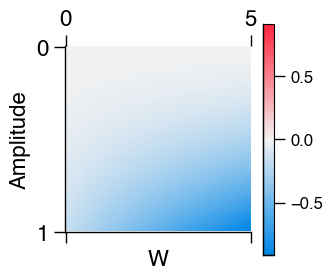

In [21]:
# Arrays
a = np.linspace(0, 1, 100) * 5
w_ij = np.linspace(0, 5, 100)

fig, axs = plot_heatmap(a, w_ij, lambda a, w: presyn_f(a, w, coefs))
axs.set_ylabel('Amplitude')
axs.set_xlabel('W')

axs.set_xticks([0, 100], [0, 5])
axs.set_yticks([0, 100], [0, 1])

Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


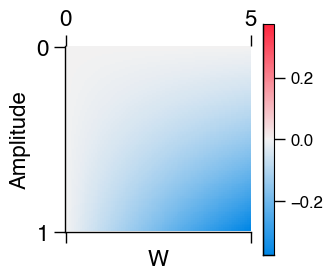

In [22]:
# Arrays
a = np.linspace(0, 1, 100) * 5
w_ij = np.linspace(0, 5, 100)

fig, axs = plot_heatmap(a, w_ij, lambda a, w: postsyn_f(a, w, coefs))
axs.set_ylabel('Amplitude')
axs.set_xlabel('W')

axs.set_xticks([0, 100], [0, 5])
axs.set_yticks([0, 100], [0, 1])

In [23]:
def plot_pairwise(a_pre, a_post, coefs, axs, fig, set_label=True, v=None):
    w_ij = np.linspace(0, 3, 101)
    t_lag = np.linspace(-0.02, 0.02, 101)
    
    fig, axs = plot_heatmap(
        w_ij,
        t_lag, lambda w, t: pairwise_f(a_pre * 5, a_post * 5, w, t, coefs) \
            + postsyn_f(a_post * 5, w, coefs, include_const=False) \
            + presyn_f(a_pre * 5, w, coefs),
        v=v,
        axs=axs,
        fig=fig,
    )
    if set_label:
        axs.set_ylabel('W')
        axs.set_xlabel(r'$t_{\rm post} - t_{\rm pre} $')
    axs.set_xticks([0, 50, 100], [-20, 0, 20])
    axs.set_yticks([0, 100], [0, 3])

In [24]:
def plot_pairwise_pre(w_ij, a_post, coefs, axs, fig, set_label=True, v=None):
    a_pre = np.linspace(0, 1, 100)
    t_lag = np.linspace(-0.02, 0.02, 100)
    
    fig, axs = plot_heatmap(
        a_pre,
        t_lag,
        lambda a_pre, t: pairwise_f(a_pre * 5, a_post * 5, w_ij, t, coefs) \
            + postsyn_f(a_post * 5, w_ij, coefs, include_const=False) \
            + presyn_f(a_pre * 5, w_ij, coefs),
        v=v,
        axs=axs,
        fig=fig,
    )
    if set_label:
        axs.set_ylabel(r'$a_{\rm pre}$')
        axs.set_xlabel(r'$t_{\rm post} - t_{\rm pre} $')
    axs.set_xticks([0, 50, 100], [-20, 0, 20])
    axs.set_yticks([0, 100], [0, 1])

[[<Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: >]]
Axes(0.125,0.653529;0.182353x0.226471)
Axes(0.31875,0.653529;0.0341912x0.226471)
Axes(0.398529,0.653529;0.182353x0.226471)
Axes(0.592279,0.653529;0.0341912x0.226471)
Axes(0.672059,0.653529;0.182353x0.226471)
Axes(0.865809,0.653529;0.0341912x0.226471)
Axes(0.125,0.381765;0.182353x0.226471)
Axes(0.31875,0.381765;0.0341912x0.226471)
Axes(0.398529,0.381765;0.182353x0.226471)
Axes(0.592279,0.381765;0.0341912x0.226471)
Axes(0.672059,0.381765;0.182353x0.226471)
Axes(0.865809,0.381765;0.0341912x0.226471)
Axes(0.125,0.11;0.182353x0.226471)
Axes(0.31875,0.11;0.0341912x0.226471)
Axes(0.398529,0.11;0.182353x0.226471)
Axes(0.592279,0.11;0.0341912x0.226471)
Axes(0.672059,0.11;0.182353x0.226471)
Axes(0.865809,0.11;0.0341912x0.226471)


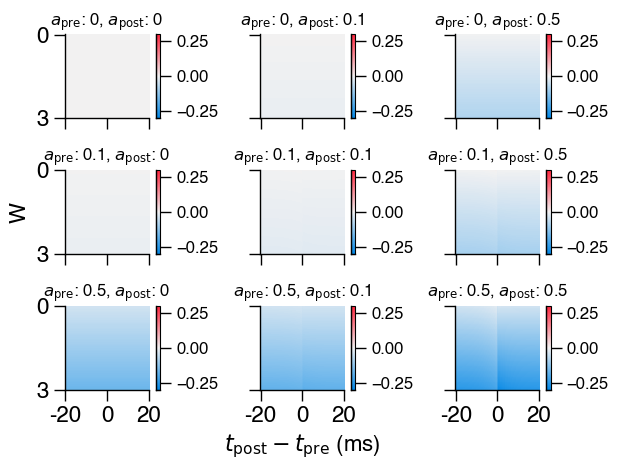

In [25]:
fig, axs = plt.subplots(3, 3, sharex=True, sharey=True)
print(axs)

conds = []
for a_pre in [0, 0.1, 0.5]:
    for a_post in [0, 0.1, 0.5]:
        conds.append((a_pre, a_post))

for i, (a_pre, a_post) in enumerate(conds):
    ax = axs[i // 3, i % 3]
    plot_pairwise(a_pre, a_post, coefs, ax, fig, set_label=False, v=0.3)
    # Only show x-ticks on bottom row
    if i // 3 != 2:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=False,
            top=False,
            labeltop=False,
        )
    else:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True,
            top=False,
            labeltop=False,
        )
    ax.set_title(r'$a_{\rm pre}$: ' + f'{a_pre}, ' + r'$a_{\rm post}$: ' + f'{a_post}')
    # Only show y-ticks on first column

axs[1, 0].set_ylabel('W')
axs[-1, 1].set_xlabel(r'$t_{\rm post} - t_{\rm pre}$ (ms)')
fig.tight_layout()

[[<Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: >]]
Axes(0.125,0.653529;0.182353x0.226471)
Axes(0.31875,0.653529;0.0341912x0.226471)
Axes(0.398529,0.653529;0.182353x0.226471)
Axes(0.592279,0.653529;0.0341912x0.226471)
Axes(0.672059,0.653529;0.182353x0.226471)
Axes(0.865809,0.653529;0.0341912x0.226471)
Axes(0.125,0.381765;0.182353x0.226471)
Axes(0.31875,0.381765;0.0341912x0.226471)
Axes(0.398529,0.381765;0.182353x0.226471)
Axes(0.592279,0.381765;0.0341912x0.226471)
Axes(0.672059,0.381765;0.182353x0.226471)
Axes(0.865809,0.381765;0.0341912x0.226471)
Axes(0.125,0.11;0.182353x0.226471)
Axes(0.31875,0.11;0.0341912x0.226471)
Axes(0.398529,0.11;0.182353x0.226471)
Axes(0.592279,0.11;0.0341912x0.226471)
Axes(0.672059,0.11;0.182353x0.226471)
Axes(0.865809,0.11;0.0341912x0.226471)


Text(0.5, 0, '$t_{\\rm post} - t_{\\rm pre}$ (ms)')

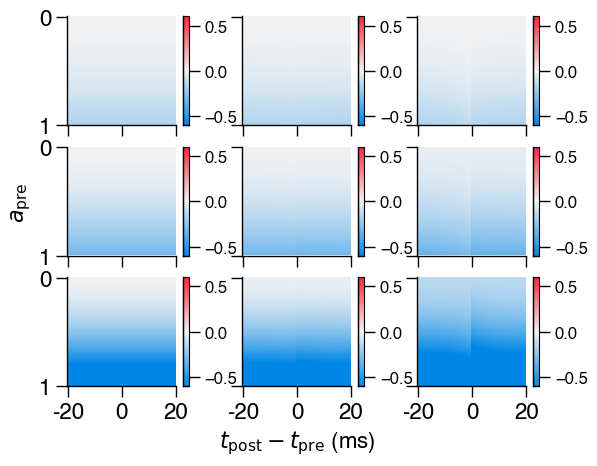

In [26]:
fig, axs = plt.subplots(3, 3, sharex=True, sharey=True)
print(axs)

conds = []
for w_ij in [0, 1, 5]:
    for a_post in [0, 0.1, 0.5]:
        conds.append((w_ij, a_post))

for i, (w_ij, a_post) in enumerate(conds):
    ax = axs[i // 3, i % 3]
    plot_pairwise_pre(w_ij, a_post, coefs, ax, fig, set_label=False, v=0.6)
    # Only show x-ticks on bottom row
    if i // 3 != 2:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=False,
            top=False,
            labeltop=False,
        )
    else:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True,
            top=False,
            labeltop=False,
        )
    # Only show y-ticks on first column

axs[1, 0].set_ylabel(r'$a_{\rm pre}$')
axs[-1, 1].set_xlabel(r'$t_{\rm post} - t_{\rm pre}$ (ms)')

In [27]:
def plot_triplet_pre(a_pre, z, coefs, axs, fig, set_label=True, v=None):
    w_ij = np.linspace(0, 10, 100)
    t_lag = np.linspace(-0.02, 0.02, 100)
    
    fig, axs = plot_heatmap(
        w_ij,
        t_lag,
        lambda w, t: three_factor_z_pre(a_pre * 5, z * 5, w, t, coefs),
        v=v,
        axs=axs,
        fig=fig,
    )
    if set_label:
        axs.set_ylabel('W')
        axs.set_xlabel(r'$t_{\rm pre} - t_{\rm z} $')
    axs.set_xticks([0, 50, 100], [-20, 0, 20])
    axs.set_yticks([0, 100], [0, 10])

In [28]:
def plot_triplet_post(a_post, z, coefs, axs, fig, set_label=True, v=None):
    w_ij = np.linspace(0, 10, 100)
    t_lag = np.linspace(-0.02, 0.02, 100)
    
    fig, axs = plot_heatmap(
        w_ij,
        t_lag,
        lambda w, t: three_factor_z_post(a_post * 5, z * 5, w, t, coefs),
        v=v, 
        axs=axs,
        fig=fig,
    )
    if set_label:
        axs.set_ylabel('W')
        axs.set_xlabel(r'$t_{\rm post} - t_{\rm z} $')
    axs.set_xticks([0, 50, 100], [-20, 0, 20])
    axs.set_yticks([0, 100], [0, 10])

In [29]:
def plot_triplet_pre_post(a_pre, a_post, z, w_ij, coefs, axs, fig, set_label=True, v=None):
    t_lag_post_z = np.linspace(0, 0.02, 100)
    t_lag_post_pre = np.linspace(-0.02, 0.02, 100)
    
    fig, axs = plot_heatmap(
        t_lag_post_z,
        t_lag_post_pre,
        lambda tl2, tl1: three_factor_pre_post_z(a_pre * 5, a_post * 5, z * 5, w_ij, tl1, tl2, coefs),
        v=v,
        axs=axs,
        fig=fig,
    )
    if set_label:
        axs.set_ylabel(r'$t_{\rm post} - t_{\rm pre} $')
        axs.set_xlabel(r'$t_{\rm post} - t_{\rm z} $')
    axs.set_xticks([0, 50, 100], [-20, 0, 20])
    axs.set_yticks([0, 100], [0, 20])

In [30]:
def plot_triplet_pre_post_w(a_pre, a_post, z, t_lag_post_z, coefs, axs, fig, set_label=True, v=None):
    w_ij = np.linspace(0, 10, 100)
    t_lag_post_pre = np.linspace(-0.02, 0.02, 100)
    
    fig, axs = plot_heatmap(
        w_ij,
        t_lag_post_pre,
        lambda w, tl1: three_factor_pre_post_z(a_pre * 5, a_post * 5, z * 5, w, tl1, t_lag_post_z, coefs),
        v=v,
        axs=axs,
        fig=fig,
    )
    if set_label:
        axs.set_ylabel(r'$t_{\rm post} - t_{\rm pre} $')
        axs.set_xlabel(r'$t_{\rm post} - t_{\rm z} $')
    axs.set_xticks([0, 50, 100], [-20, 0, 20])
    axs.set_yticks([0, 100], [0, 20])

[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]
Axes(0.125,0.53;0.281818x0.35)
Axes(0.424432,0.53;0.0528409x0.35)
Axes(0.547727,0.53;0.281818x0.35)
Axes(0.847159,0.53;0.0528409x0.35)
Axes(0.125,0.11;0.281818x0.35)
Axes(0.424432,0.11;0.0528409x0.35)
Axes(0.547727,0.11;0.281818x0.35)
Axes(0.847159,0.11;0.0528409x0.35)


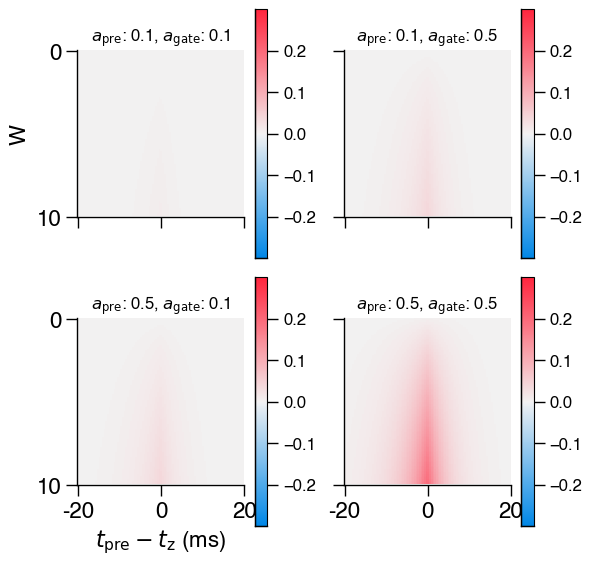

In [31]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(6, 6))
print(axs)

conds = []
for a_pre in [0.1, 0.5]:
    for z in [0.1, 0.5]:
        conds.append((a_pre, z))

for i, (a_pre, z) in enumerate(conds):
    ax = axs[i // 2, i % 2]
    plot_triplet_pre(a_pre, z, coefs, ax, fig, set_label=False, v=0.3)
    # Only show x-ticks on bottom row
    if i // 2 != 1:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=False,
            top=False,
            labeltop=False,
        )
    else:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True,
            top=False,
            labeltop=False,
        )
    ax.set_title(r'$a_{\rm pre}$: ' + f'{a_pre}, ' + r'$a_{\rm gate}$: ' + f'{z}')
    # Only show y-ticks on first column

axs[0, 0].set_ylabel('W')
axs[1, 0].set_xlabel(r'$t_{\rm pre} - t_{\rm z}$ (ms)')
fig.tight_layout()

[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]
Axes(0.125,0.53;0.281818x0.35)
Axes(0.424432,0.53;0.0528409x0.35)
Axes(0.547727,0.53;0.281818x0.35)
Axes(0.847159,0.53;0.0528409x0.35)
Axes(0.125,0.11;0.281818x0.35)
Axes(0.424432,0.11;0.0528409x0.35)
Axes(0.547727,0.11;0.281818x0.35)
Axes(0.847159,0.11;0.0528409x0.35)


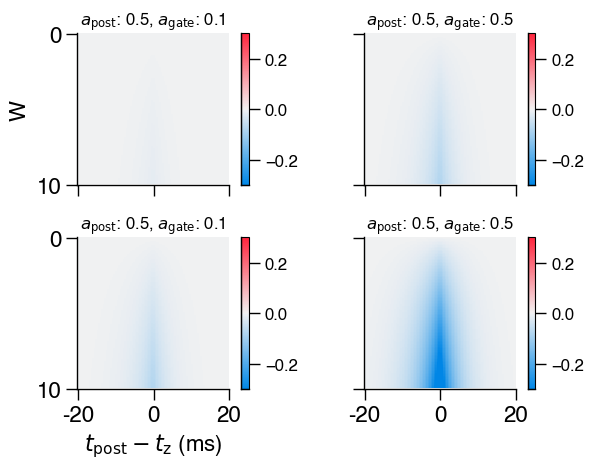

In [32]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
print(axs)

conds = []
for a_post in [0.1, 0.5]:
    for z in [0.1, 0.5]:
        conds.append((a_post, z))

for i, (a_post, z) in enumerate(conds):
    ax = axs[i // 2, i % 2]
    plot_triplet_post(a_post, z, coefs, ax, fig, set_label=False, v=0.3)
    # Only show x-ticks on bottom row
    if i // 2 != 1:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=False,
            top=False,
            labeltop=False,
        )
    else:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True,
            top=False,
            labeltop=False,
        )
    ax.set_title(r'$a_{\rm post}$: ' + f'{a_pre}, ' + r'$a_{\rm gate}$: ' + f'{z}')
    # Only show y-ticks on first column

axs[0, 0].set_ylabel('W')
axs[1, 0].set_xlabel(r'$t_{\rm post} - t_{\rm z}$ (ms)')
fig.tight_layout()

[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]
Axes(0.125,0.53;0.281818x0.35)
Axes(0.424432,0.53;0.0528409x0.35)
Axes(0.547727,0.53;0.281818x0.35)
Axes(0.847159,0.53;0.0528409x0.35)
Axes(0.125,0.11;0.281818x0.35)
Axes(0.424432,0.11;0.0528409x0.35)
Axes(0.547727,0.11;0.281818x0.35)
Axes(0.847159,0.11;0.0528409x0.35)


Text(0.5, 0, '$t_{\\rm post} - t_{\\rm pre}$ (ms)')

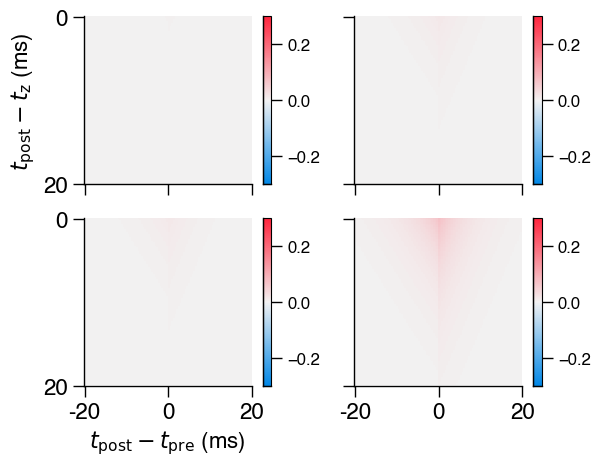

In [33]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
print(axs)

conds = []
for a_pre in [0.1, 0.5]:
    for a_post in [0.1, 0.5]:
        conds.append((a_pre, a_post))
z = 1
w_ij = 0.1

for i, (a_post, z) in enumerate(conds):
    ax = axs[i // 2, i % 2]
    plot_triplet_pre_post(a_pre, a_post, z, w_ij, coefs, ax, fig, set_label=False, v=0.3)
    # Only show x-ticks on bottom row
    if i // 2 != 1:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=False,
            top=False,
            labeltop=False,
        )
    else:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True,
            top=False,
            labeltop=False,
        )
    # Only show y-ticks on first column

axs[0, 0].set_ylabel(r'$t_{\rm post} - t_{\rm z}$ (ms)')
axs[1, 0].set_xlabel(r'$t_{\rm post} - t_{\rm pre}$ (ms)')

[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]
Axes(0.125,0.53;0.281818x0.35)
Axes(0.424432,0.53;0.0528409x0.35)
Axes(0.547727,0.53;0.281818x0.35)
Axes(0.847159,0.53;0.0528409x0.35)
Axes(0.125,0.11;0.281818x0.35)
Axes(0.424432,0.11;0.0528409x0.35)
Axes(0.547727,0.11;0.281818x0.35)
Axes(0.847159,0.11;0.0528409x0.35)


Text(0.5, 0, '$t_{\\rm post} - t_{\\rm pre}$ (ms)')

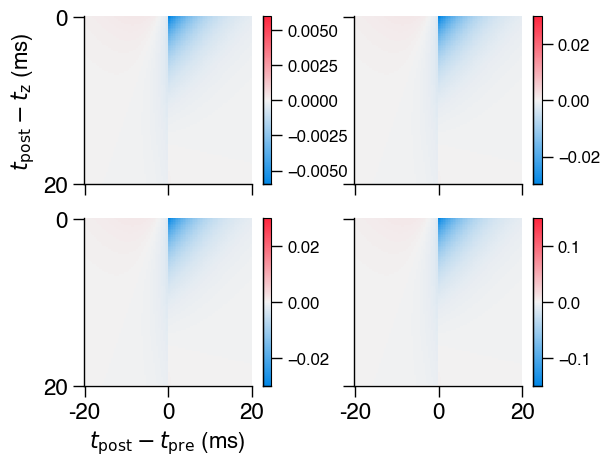

In [34]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
print(axs)

conds = []
for a_pre in [0.1, 0.5]:
    for a_post in [0.1, 0.5]:
        conds.append((a_pre, a_post))
z = 1
w_ij = 5

for i, (a_post, z) in enumerate(conds):
    ax = axs[i // 2, i % 2]
    plot_triplet_pre_post(a_pre, a_post, z, w_ij, coefs, ax, fig, set_label=False)
    # Only show x-ticks on bottom row
    if i // 2 != 1:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=False,
            top=False,
            labeltop=False,
        )
    else:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True,
            top=False,
            labeltop=False,
        )
    # Only show y-ticks on first column

axs[0, 0].set_ylabel(r'$t_{\rm post} - t_{\rm z}$ (ms)')
axs[1, 0].set_xlabel(r'$t_{\rm post} - t_{\rm pre}$ (ms)')

[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]
Axes(0.125,0.53;0.281818x0.35)
Axes(0.424432,0.53;0.0528409x0.35)
Axes(0.547727,0.53;0.281818x0.35)
Axes(0.847159,0.53;0.0528409x0.35)
Axes(0.125,0.11;0.281818x0.35)
Axes(0.424432,0.11;0.0528409x0.35)
Axes(0.547727,0.11;0.281818x0.35)
Axes(0.847159,0.11;0.0528409x0.35)


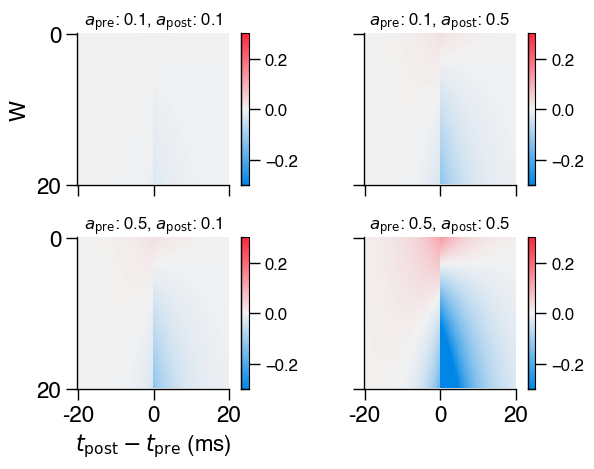

In [35]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
print(axs)

conds = []
for a_pre in [0.1, 0.5]:
    for a_post in [0.1, 0.5]:
        conds.append((a_pre, a_post))
z = 1
t_lag_post_z = 0.001

for i, (a_pre, a_post) in enumerate(conds):
    ax = axs[i // 2, i % 2]
    plot_triplet_pre_post_w(a_pre, a_post, z, t_lag_post_z, coefs, ax, fig, set_label=False, v=0.3)
    # Only show x-ticks on bottom row
    if i // 2 != 1:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=False,
            top=False,
            labeltop=False,
        )
    else:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True,
            top=False,
            labeltop=False,
        )
    ax.set_title(r'$a_{\rm pre}$: ' + f'{a_pre}, ' + r'$a_{\rm post}$: ' + f'{a_post}')
    # Only show y-ticks on first column

axs[0, 0].set_ylabel('W')
axs[1, 0].set_xlabel(r'$t_{\rm post} - t_{\rm pre}$ (ms)')
fig.tight_layout()

In [47]:
def plot_all(a_pre, a_post, z, t_lag_post_z, coefs, axs, fig, set_label=True, v=None):
    w_ij = np.linspace(0, 1, 101)
    t_lag = np.linspace(-0.02, 0.02, 101)
    
    fig, axs = plot_heatmap(
        w_ij,
        t_lag,
        lambda w, t: pairwise_f(a_pre * 5, a_post * 5, w, t, coefs) \
            + postsyn_f(a_post * 5, w, coefs, include_const=False) \
            + presyn_f(a_pre * 5, w, coefs) \
            + three_factor_z_pre(a_pre * 5, z * 5, w, t_lag_post_z - t, coefs) \
            + three_factor_z_post(a_post * 5, z * 5, w, t_lag_post_z, coefs) \
            + three_factor_pre_post_z(a_pre * 5, a_post * 5, z * 5, w, t, t_lag_post_z, coefs),
        v=v,
        axs=axs,
        fig=fig,
    )
    if set_label:
        axs.set_ylabel('W')
        axs.set_xlabel(r'$t_{\rm post} - t_{\rm pre} $')
    axs.set_xticks([0, 50, 100], [-20, 0, 20])
    axs.set_yticks([0, 100], [0, 1])

[[<Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: >]]
Axes(0.125,0.653529;0.182353x0.226471)
Axes(0.31875,0.653529;0.0341912x0.226471)
Axes(0.398529,0.653529;0.182353x0.226471)
Axes(0.592279,0.653529;0.0341912x0.226471)
Axes(0.672059,0.653529;0.182353x0.226471)
Axes(0.865809,0.653529;0.0341912x0.226471)
Axes(0.125,0.381765;0.182353x0.226471)
Axes(0.31875,0.381765;0.0341912x0.226471)
Axes(0.398529,0.381765;0.182353x0.226471)
Axes(0.592279,0.381765;0.0341912x0.226471)
Axes(0.672059,0.381765;0.182353x0.226471)
Axes(0.865809,0.381765;0.0341912x0.226471)
Axes(0.125,0.11;0.182353x0.226471)
Axes(0.31875,0.11;0.0341912x0.226471)
Axes(0.398529,0.11;0.182353x0.226471)
Axes(0.592279,0.11;0.0341912x0.226471)
Axes(0.672059,0.11;0.182353x0.226471)
Axes(0.865809,0.11;0.0341912x0.226471)


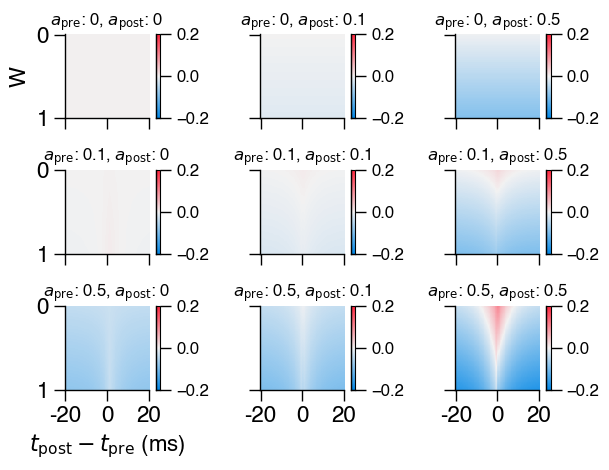

In [50]:
fig, axs = plt.subplots(3, 3, sharex=True, sharey=True)
print(axs)

conds = []
for a_pre in [0, 0.1, 0.5]:
    for a_post in [0, 0.1, 0.5]:
        conds.append((a_pre, a_post))
z = 1
t_lag_post_z = 0.001

for i, (a_pre, a_post) in enumerate(conds):
    ax = axs[i // 3, i % 3]
    plot_all(a_pre, a_post, z, t_lag_post_z, coefs, ax, fig, set_label=False, v=0.2)
    # Only show x-ticks on bottom row
    if i // 3 != 2:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=False,
            top=False,
            labeltop=False,
        )
    else:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True,
            top=False,
            labeltop=False,
        )
    ax.set_title(r'$a_{\rm pre}$: ' + f'{a_pre}, ' + r'$a_{\rm post}$: ' + f'{a_post}')

axs[0, 0].set_ylabel('W')
axs[2, 0].set_xlabel(r'$t_{\rm post} - t_{\rm pre}$ (ms)')
fig.tight_layout()

[[<Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: >]]
Axes(0.125,0.653529;0.182353x0.226471)
Axes(0.31875,0.653529;0.0341912x0.226471)
Axes(0.398529,0.653529;0.182353x0.226471)
Axes(0.592279,0.653529;0.0341912x0.226471)
Axes(0.672059,0.653529;0.182353x0.226471)
Axes(0.865809,0.653529;0.0341912x0.226471)
Axes(0.125,0.381765;0.182353x0.226471)
Axes(0.31875,0.381765;0.0341912x0.226471)
Axes(0.398529,0.381765;0.182353x0.226471)
Axes(0.592279,0.381765;0.0341912x0.226471)
Axes(0.672059,0.381765;0.182353x0.226471)
Axes(0.865809,0.381765;0.0341912x0.226471)
Axes(0.125,0.11;0.182353x0.226471)
Axes(0.31875,0.11;0.0341912x0.226471)
Axes(0.398529,0.11;0.182353x0.226471)
Axes(0.592279,0.11;0.0341912x0.226471)
Axes(0.672059,0.11;0.182353x0.226471)
Axes(0.865809,0.11;0.0341912x0.226471)


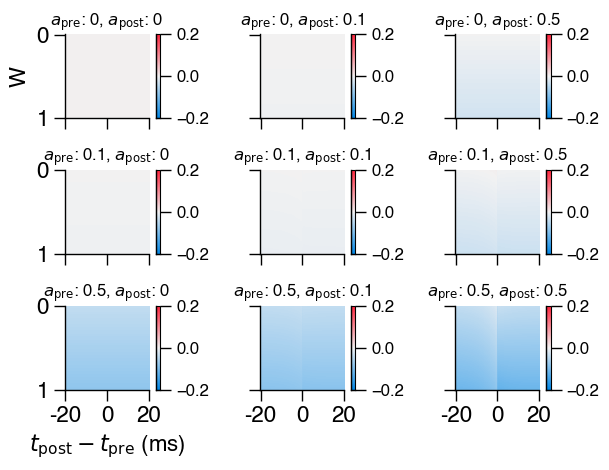

In [51]:
fig, axs = plt.subplots(3, 3, sharex=True, sharey=True)
print(axs)

conds = []
for a_pre in [0, 0.1, 0.5]:
    for a_post in [0, 0.1, 0.5]:
        conds.append((a_pre, a_post))
z = 0
t_lag_post_z = 0.001

for i, (a_pre, a_post) in enumerate(conds):
    ax = axs[i // 3, i % 3]
    plot_all(a_pre, a_post, z, t_lag_post_z, coefs, ax, fig, set_label=False, v=0.2)
    # Only show x-ticks on bottom row
    if i // 3 != 2:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=False,
            top=False,
            labeltop=False,
        )
    else:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True,
            top=False,
            labeltop=False,
        )
    ax.set_title(r'$a_{\rm pre}$: ' + f'{a_pre}, ' + r'$a_{\rm post}$: ' + f'{a_post}')

axs[0, 0].set_ylabel('W')
axs[2, 0].set_xlabel(r'$t_{\rm post} - t_{\rm pre}$ (ms)')
fig.tight_layout()